In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "WenQuanYi Micro Hei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

from config import TRAIN_FILE, TEST_FILE, TFIDF_MODEL_FILE, FIGURES_DIR, MODELS_DIR, JUNK_CLF_MODEL_FILE, JUNK_NB_ALPHA

train_df = pd.read_csv(str(TRAIN_FILE), encoding="utf-8-sig")
test_df = pd.read_csv(str(TEST_FILE), encoding="utf-8-sig")

# 提取标签
y_train = train_df["is_junk"].astype(int)
y_test = test_df["is_junk"].astype(int)

print(f"训练集: {len(train_df)} 条")
print(f"  技术帖: {(y_train == 0).sum()}")
print(f"  垃圾帖: {(y_train == 1).sum()}")
print(f"  垃圾占比: {y_train.mean() * 100:.1f}%")
print(f"\n测试集: {len(test_df)} 条")
print(f"  技术帖: {(y_test == 0).sum()}")
print(f"  垃圾帖: {(y_test == 1).sum()}")
print(f"  垃圾占比: {y_test.mean() * 100:.1f}%")

训练集: 6181 条
  技术帖: 2041
  垃圾帖: 4140
  垃圾占比: 67.0%

测试集: 1546 条
  技术帖: 511
  垃圾帖: 1035
  垃圾占比: 66.9%


In [3]:
vectorizer = joblib.load(str(TFIDF_MODEL_FILE))

X_train = vectorizer.transform(train_df["processed_text"].fillna("").astype(str))
X_test = vectorizer.transform(test_df["processed_text"].fillna("").astype(str))

print(f"训练集特征矩阵: {X_train.shape}")
print(f"测试集特征矩阵: {X_test.shape}")

训练集特征矩阵: (6181, 5000)
测试集特征矩阵: (1546, 5000)


In [4]:
from sklearn.naive_bayes import MultinomialNB

nb_clf = MultinomialNB(alpha=JUNK_NB_ALPHA)
nb_clf.fit(X_train, y_train)

nb_train_acc = nb_clf.score(X_train, y_train)
nb_test_acc = nb_clf.score(X_test, y_test)

print("MultinomialNB")
print(f"  alpha (拉普拉斯平滑): {JUNK_NB_ALPHA}")
print(f"  训练集准确率: {nb_train_acc:.4f}")
print(f"  测试集准确率: {nb_test_acc:.4f}")

MultinomialNB
  alpha (拉普拉斯平滑): 1.0
  训练集准确率: 0.9770
  测试集准确率: 0.9489


In [5]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC 本身不输出概率，用 CalibratedClassifierCV 包装以获得 predict_proba
raw_svm = LinearSVC(C=1.0, max_iter=5000, random_state=42)
svm_clf = CalibratedClassifierCV(raw_svm, cv=3)
svm_clf.fit(X_train, y_train)

svm_train_acc = svm_clf.score(X_train, y_train)
svm_test_acc = svm_clf.score(X_test, y_test)

print("LinearSVC (Calibrated)")
print(f"  C (正则化): 1.0")
print(f"  训练集准确率: {svm_train_acc:.4f}")
print(f"  测试集准确率: {svm_test_acc:.4f}")

LinearSVC (Calibrated)
  C (正则化): 1.0
  训练集准确率: 0.9964
  测试集准确率: 0.9489


C:\Users\62653\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\62653\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\62653\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


MultinomialNB 分类报告:
              precision    recall  f1-score   support

     技术帖 (0)       0.96      0.89      0.92       511
     垃圾帖 (1)       0.95      0.98      0.96      1035

    accuracy                           0.95      1546
   macro avg       0.95      0.93      0.94      1546
weighted avg       0.95      0.95      0.95      1546

LinearSVC 分类报告:
              precision    recall  f1-score   support

     技术帖 (0)       0.93      0.91      0.92       511
     垃圾帖 (1)       0.96      0.97      0.96      1035

    accuracy                           0.95      1546
   macro avg       0.94      0.94      0.94      1546
weighted avg       0.95      0.95      0.95      1546


混淆矩阵图已保存: D:\code-hub\ml-service\outputs\figures\junk_confusion_matrix.png


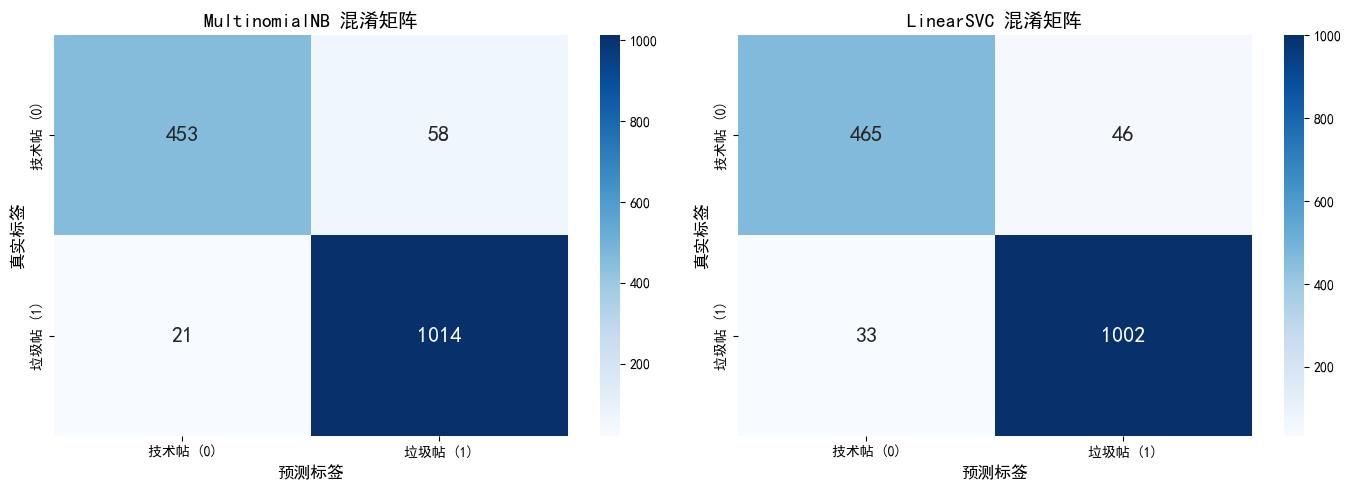

In [6]:
from sklearn.metrics import classification_report, confusion_matrix

target_names = ["技术帖 (0)", "垃圾帖 (1)"]

# ── NB 评估 ──
nb_pred = nb_clf.predict(X_test)
print("=" * 55)
print("MultinomialNB 分类报告:")
print("=" * 55)
print(classification_report(y_test, nb_pred, target_names=target_names))

# ── SVM 评估 ──
svm_pred = svm_clf.predict(X_test)
print("=" * 55)
print("LinearSVC 分类报告:")
print("=" * 55)
print(classification_report(y_test, svm_pred, target_names=target_names))

# ── 混淆矩阵可视化 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, name in [(axes[0], nb_pred, "MultinomialNB"), (axes[1], svm_pred, "LinearSVC")]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=target_names, yticklabels=target_names,
        ax=ax, annot_kws={"size": 16},
    )
    ax.set_title(f"{name} 混淆矩阵", fontsize=14)
    ax.set_xlabel("预测标签", fontsize=12)
    ax.set_ylabel("真实标签", fontsize=12)

plt.tight_layout()
os.makedirs(str(FIGURES_DIR), exist_ok=True)
fig.savefig(str(FIGURES_DIR / "junk_confusion_matrix.png"), dpi=200)
print(f"\n混淆矩阵图已保存: {FIGURES_DIR / 'junk_confusion_matrix.png'}")
plt.show()

In [7]:
from sklearn.metrics import f1_score

nb_f1 = f1_score(y_test, nb_pred)
svm_f1 = f1_score(y_test, svm_pred)

print(f"NB  F1 (垃圾类): {nb_f1:.4f}")
print(f"SVM F1 (垃圾类): {svm_f1:.4f}")

# 选 F1 更高的
if svm_f1 >= nb_f1:
    best_clf = svm_clf
    best_name = "LinearSVC"
else:
    best_clf = nb_clf
    best_name = "MultinomialNB"

print(f"\n选定模型: {best_name}")

os.makedirs(str(MODELS_DIR), exist_ok=True)
joblib.dump(best_clf, str(JUNK_CLF_MODEL_FILE))
print(f"已保存: {JUNK_CLF_MODEL_FILE}")
print(f"文件大小: {os.path.getsize(str(JUNK_CLF_MODEL_FILE)) / 1024:.1f} KB")

# 验证
loaded = joblib.load(str(JUNK_CLF_MODEL_FILE))
test_texts = ["React组件怎么传值", "今天好累不想上班"]
test_vecs = vectorizer.transform(test_texts)
preds = loaded.predict(test_vecs)
for text, pred in zip(test_texts, preds):
    label = "垃圾" if pred == 1 else "技术"
    print(f"  '{text}' → {label}")

NB  F1 (垃圾类): 0.9625
SVM F1 (垃圾类): 0.9621

选定模型: MultinomialNB
已保存: D:\code-hub\ml-service\models\junk_classifier.pkl
文件大小: 157.0 KB
  'React组件怎么传值' → 垃圾
  '今天好累不想上班' → 垃圾


In [8]:
best_pred = best_clf.predict(X_test)

# 假阳性：技术帖被误判为垃圾
fp_mask = (y_test == 0) & (best_pred == 1)
fp_samples = test_df[fp_mask.values]

# 假阴性：垃圾帖被漏判为技术
fn_mask = (y_test == 1) & (best_pred == 0)
fn_samples = test_df[fn_mask.values]

print(f"误判分析 ({best_name}):")
print(f"  假阳性 (技术→垃圾): {len(fp_samples)} 条")
print(f"  假阴性 (垃圾→技术): {len(fn_samples)} 条")

if len(fp_samples) > 0:
    print(f"\n假阳性样本 (技术帖被误判为垃圾):")
    for _, row in fp_samples.iterrows():
        print(f"  [{row['category']}] {row['content'][:60]}")

if len(fn_samples) > 0:
    print(f"\n假阴性样本 (垃圾帖被漏判为技术):")
    for _, row in fn_samples.iterrows():
        print(f"  {row['content'][:60]}")

if len(fp_samples) == 0 and len(fn_samples) == 0:
    print("\n没有误判样本，分类器表现完美！")

误判分析 (MultinomialNB):
  假阳性 (技术→垃圾): 58 条
  假阴性 (垃圾→技术): 21 条

假阳性样本 (技术帖被误判为垃圾):
  [DevOps] 一次面试让我重新认识了 Cursor。上周面试的时候，面试官突然问我：“你用过 Cursor 对吧，那你知道 rules
  [网络] 四章术士被改弱了吗？术士的形象本来就不好。个头小，还老低头，总像。术士的形象本来就不好。个头小，还老低头，总像做了亏心事
  [DevOps] 这几天怎么总关服务器啊我这几天刚好有点时间来玩，可是怎么总是关服。我这几天刚好有点时间来玩，可是怎么总是关啊，也不先在管
  [AI/ML] Ghost互联网。在我一直以来最喜欢的动画《玩具总动员》中有这样一个场景——如果你看过这部电影，不用我多说你也知道——安
  [DevOps] Jetbrains正式宣布免费，有点猛啊！。提到 Jetbrains 这家公司，相信搞开发的同学应该都不陌生。 该公司盛
  [网络配置] 企业为何必须要建设网站？。因为现在是信息化的社会呀，生活中不可能没有信息的呀，如果有客户想了解你的信息和产品性能等方面，
  [AI/ML] 库克告别苹果，「九子夺嫡」争夺 CEO 大战开始了。苹果高层大地震！65 岁的库克开始手抖，低调的他意图引退，而留下来的
  [后端] 有个同事因为恐惧 AI 要离职了。AI的发展有没有超出你的想象？你有没有因为AI而产生过焦虑？焦虑过后你选择离开这个行业
  [网络协议] 20分求助！我要辞工啊！但老板不放人！要我干完一个月才能走！帮我?。签订协议了么？如果是，就不好办法，因为你需要付违反协
  [网络] 最近有没有送电脑和现金的活动有送现金和电脑的活动，不知是不是真的。有送现金和的活动，不知是不是真的？
  [网络] 光电鼠标不移动了新买的,刚用的时候好好的,用一会就出现有时候卡在。新买的,刚用的时候好好的,用一会就出现有时候卡在那移动
  [AI/ML] 用 AI 自动生成教育视频，解决孩子的"十万个为什么"。家里有小孩的朋友应该都有这样的体验：孩子总会问一些奇怪的问题。 
  [编程技术] 本年增加数和本年转回数是什么意思本年增加数：根据各个减值准备类会。本年增加数：根据各个减值准备类账户的贷方发生额的填列 
  [网络协议] 我们离婚是协议离